In [1]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

class PlotStyleManager:
    def __init__(self, folders):
        self.folders = folders
        self.parent_colors = {}
        self.subcat_styles = {}
        self.line_styles = ['-', '--', '-.', ':']
        
        # 1. Assign consistent base colors to Parent Categories
        cmap = plt.get_cmap('tab20')
        for i, parent in enumerate(self.folders):
            self.parent_colors[parent] = cmap(i % 20)
            
        # 2. Assign consistent linestyles to Subcategories
        self._build_subcategory_mappings()

    def _build_subcategory_mappings(self):
        parent_style_counter = {parent: 0 for parent in self.folders}
        
        for folder in self.folders:
            lookup_path = os.path.join(folder, 'cat_lookup_table.csv')
            if os.path.exists(lookup_path):
                df_lkp = pd.read_csv(lookup_path)
                df_lkp.columns = df_lkp.columns.str.strip()
                
                # Extract unique subcategories, sort them so the assignment is always the same
                if 'subcategory' in df_lkp.columns:
                    unique_subcats = sorted(df_lkp['subcategory'].dropna().unique())
                    
                    for sub in unique_subcats:
                        # Assign the next available linestyle for this parent
                        style_idx = parent_style_counter[folder] % len(self.line_styles)
                        self.subcat_styles[sub] = {
                            'parent': folder,
                            'color': self.parent_colors[folder],
                            'linestyle': self.line_styles[style_idx]
                        }
                        parent_style_counter[folder] += 1

    def get_style(self, subcategory):
        """Returns a dictionary with the parent name, color, and linestyle."""
        # Fallback for unknown subcategories
        return self.subcat_styles.get(subcategory, {
            'parent': 'Unknown', 
            'color': 'gray', 
            'linestyle': '-'
        })

# --- Initialize the Global Manager ---
ROOT_FOLDERS = [
    'Baby_product', 'Confectionary', 'Dairy', 'Dry_Food', 
    'Egg_and_soy', 'Frozen', 'Instant_food', 'Processed_food', 
    'Spice', 'Veg_Fruit'
]

# Create the style manager instance to use in all future cells
style_config = PlotStyleManager(ROOT_FOLDERS)
print("✅ Global styling configuration loaded successfully.")

✅ Global styling configuration loaded successfully.


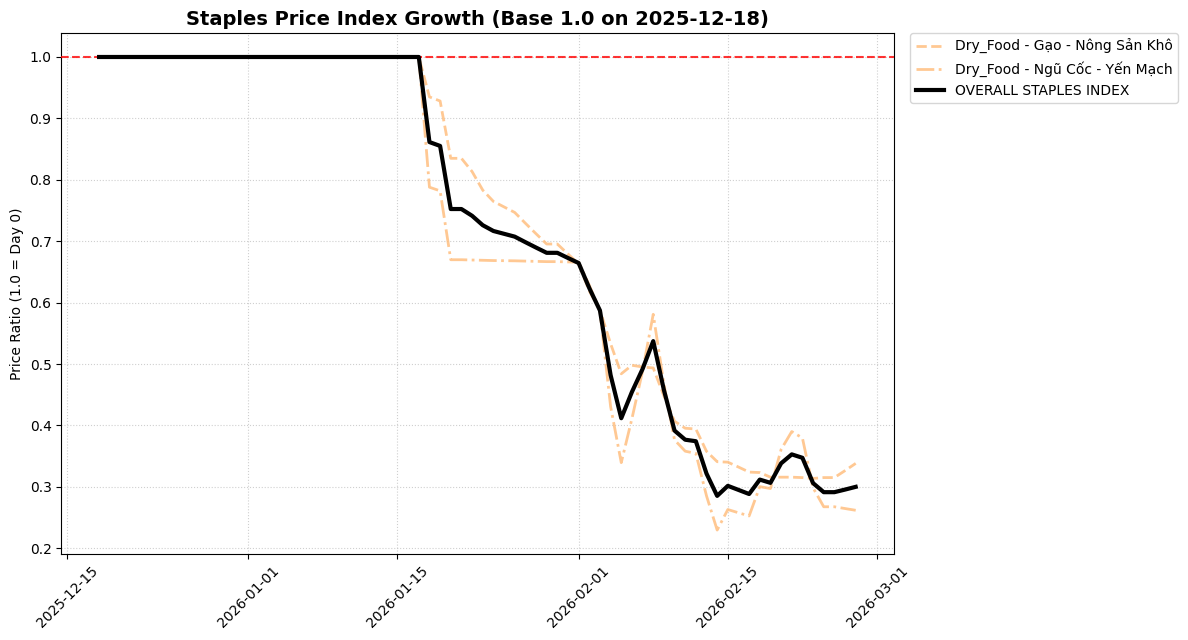

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# --- Configuration ---
CSV_PATH = '/Users/my/Online Food Price/Dry_Food/mom_price_change.csv'
START_DATE = '2025-12-18'

def generate_staples_index_plot():
    # 1. Load the data
    try:
        df = pd.read_csv(CSV_PATH, parse_dates=['date'])
    except FileNotFoundError:
        print(f"❌ Error: File not found at {CSV_PATH}")
        return

    # --- DEBUGGING: CLEAN COLUMNS ---
    # This removes extra spaces and ensures common dash issues are fixed
    df.columns = df.columns.str.strip().str.replace('–', '-') 
    
    # 2. Filter and sort
    df = df[df['date'] >= START_DATE].sort_values('date').copy()
    
    if df.empty:
        print(f"❌ Error: No data found after {START_DATE}. Check your date format or range.")
        return

    # 3. Target subcategories
    staple_cols = ['Gạo - Nông Sản Khô', 'Ngũ Cốc - Yến Mạch']
    
    # 4. Calculate Cumulative Index
    index_cols = []
    valid_staples = [] # Added to track the original names for the style manager
    
    for col in staple_cols:
        if col in df.columns:
            # Ensure we are working with numeric data and handle NaNs
            ratios = pd.to_numeric(df[col], errors='coerce').fillna(1.0).values.copy()
            
            # Baseline Day 0
            ratios[0] = 1.0  
            
            idx_name = f'{col}_index'
            df[idx_name] = np.cumprod(ratios)
            index_cols.append(idx_name)
            valid_staples.append(col) # Store original name
        else:
            print(f"⚠️ Warning: Column '{col}' not found in CSV. Check spelling!")
    
    # 5. Create Average Index
    if index_cols:
        df['staples_avg_index'] = df[index_cols].mean(axis=1)
    else:
        print("❌ No valid staple columns found. Nothing to plot.")
        return

    # --- Plotting ---
    fig, ax = plt.subplots(figsize=(12, 6.5))
    
    # Apply the systematic color scheme
    for orig_col, col_idx in zip(valid_staples, index_cols):
        valid_df = df.dropna(subset=[col_idx])
        
        # Query the global style manager using the original subcategory name
        style_info = style_config.get_style(orig_col)
        parent_name = style_info['parent']
        plot_color = style_info['color']
        plot_style = style_info['linestyle']
        
        ax.plot(valid_df['date'], valid_df[col_idx], 
                label=f'{parent_name} - {orig_col}', 
                color=plot_color, linestyle=plot_style, linewidth=2, alpha=0.8)

    # Plot the combined average
    if 'staples_avg_index' in df.columns:
        valid_avg = df.dropna(subset=['staples_avg_index'])
        ax.plot(valid_avg['date'], valid_avg['staples_avg_index'], 
                label='OVERALL STAPLES INDEX', color='black', linewidth=3, zorder=10)

    # Styling
    ax.axhline(1.0, color='red', linestyle='--', linewidth=1.5, alpha=0.8, zorder=5) 
    ax.set_title(f'Staples Price Index Growth (Base 1.0 on {START_DATE})', fontsize=14, fontweight='bold')
    ax.set_ylabel('Price Ratio (1.0 = Day 0)')
    ax.grid(True, linestyle=':', alpha=0.6)
    
    # Date formatting
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.xticks(rotation=45)
    
    # Legend adjusted for outside placement to match your other plots
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # Note: style_config must exist in your Jupyter memory from the earlier cell
    generate_staples_index_plot()

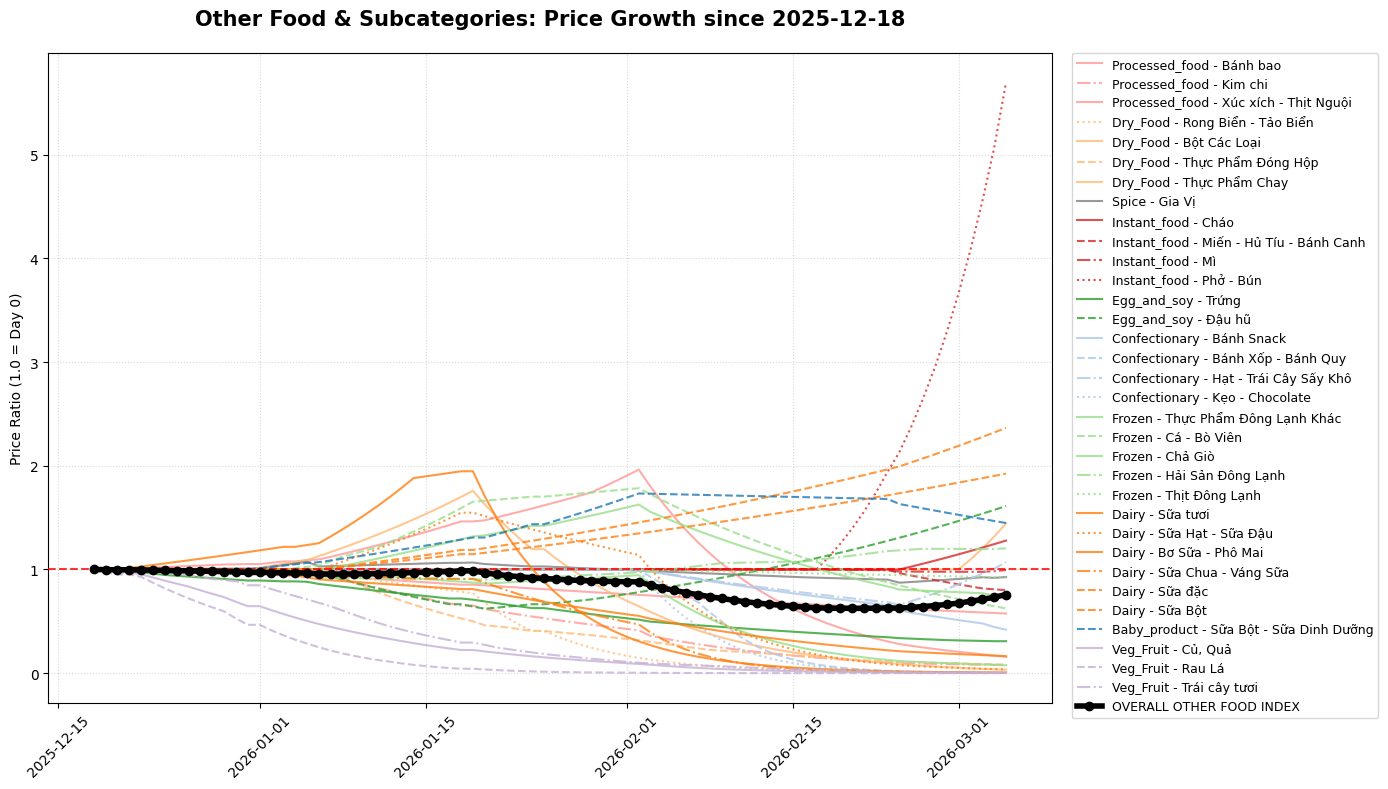

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from pathlib import Path

# --- Configuration ---
ROOT_DIR = Path('/Users/my/Online Food Price')
START_DATE = '2025-12-18'

def plot_other_food_with_subcats():
    all_dfs = []
    col_to_parent = {} # Track parents as a fallback for the style manager
    staple_targets = ['Gạo - Nông Sản Khô', 'Ngũ Cốc - Yến Mạch', 'Bánh mì', 'Thực Phẩm Chế Biến Khác']

    # 1. Gather all subcategory data
    for file_path in ROOT_DIR.rglob('jevons_price_index.csv'):
        try:
            df = pd.read_csv(file_path, parse_dates=['date'])
            category_folder = file_path.parent.name
            
            # Special filter for Baby_product
            if category_folder == 'Baby_product':
                target_col = 'Sữa Bột - Sữa Dinh Dưỡng'
                if target_col in df.columns:
                    df = df[['date', target_col]]
                else: continue
            
            df = df.set_index('date').resample('D').mean() # Ensure daily frequency
            
            # Record the parent folder for fallback labeling
            for col in df.columns:
                col_to_parent[col] = category_folder
                
            all_dfs.append(df)
        except Exception: continue

    if not all_dfs:
        print("❌ No data found.")
        return

    # 2. Combine and filter for Day 0
    combined_df = pd.concat(all_dfs, axis=1)
    # Safety check: remove duplicated columns if any exist from multiple reads
    combined_df = combined_df.loc[:, ~combined_df.columns.duplicated()] 
    combined_df = combined_df[combined_df.index >= START_DATE].sort_index()
    
    # 3. Identify "Other Food" columns
    other_cols = [col for col in combined_df.columns if col not in staple_targets]
    
    # 4. Calculate Cumulative Indices (Base 1.0 on Dec 18)
    cum_df = pd.DataFrame(index=combined_df.index)
    
    for col in other_cols:
        ratios = combined_df[col].fillna(1.0).values.copy()
        ratios[0] = 1.0  # Force Day 0 to baseline
        cum_df[col] = np.cumprod(ratios)

    # Calculate the aggregate "Other Food" Average
    cum_df['OTHER_FOOD_AVG'] = cum_df[other_cols].mean(axis=1)

    # --- Plotting ---
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # 5. Plot each subcategory using the Global Style Manager
    for col in other_cols:
        # Query the global style manager
        style_info = style_config.get_style(col)
        
        # Determine the parent name, utilizing the fallback if it's not in the lookup table
        parent_name = style_info['parent']
        if parent_name == 'Unknown':
            parent_name = col_to_parent.get(col, 'Unknown')
            
        plot_color = style_info['color']
        plot_style = style_info['linestyle']
        
        ax.plot(cum_df.index, cum_df[col], 
                label=f'{parent_name} - {col}', 
                color=plot_color, linestyle=plot_style, linewidth=1.5, alpha=0.8)

    # 6. Plot the main average (Bold/Thick line)
    ax.plot(cum_df.index, cum_df['OTHER_FOOD_AVG'], 
            label='OVERALL OTHER FOOD INDEX', 
            color='black', linewidth=4, marker='o', markersize=6, zorder=10)

    # Styling
    ax.axhline(1.0, color='red', linestyle='--', linewidth=1.5, alpha=0.8, zorder=5) # Day 0 Baseline
    ax.set_title(f'Other Food & Subcategories: Price Growth since {START_DATE}', 
                 fontsize=15, fontweight='bold', pad=20)
    ax.set_ylabel('Price Ratio (1.0 = Day 0)')
    ax.grid(True, linestyle=':', alpha=0.5)
    
    # Formatting
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.xticks(rotation=45)
    
    # Legend - formatted into 2 columns for better readability with many subcategories
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0., fontsize=9)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # Ensure style_config has been initialized in your notebook before running this
    plot_other_food_with_subcats()

✅ Found 11 Bánh mì products in lookup table.


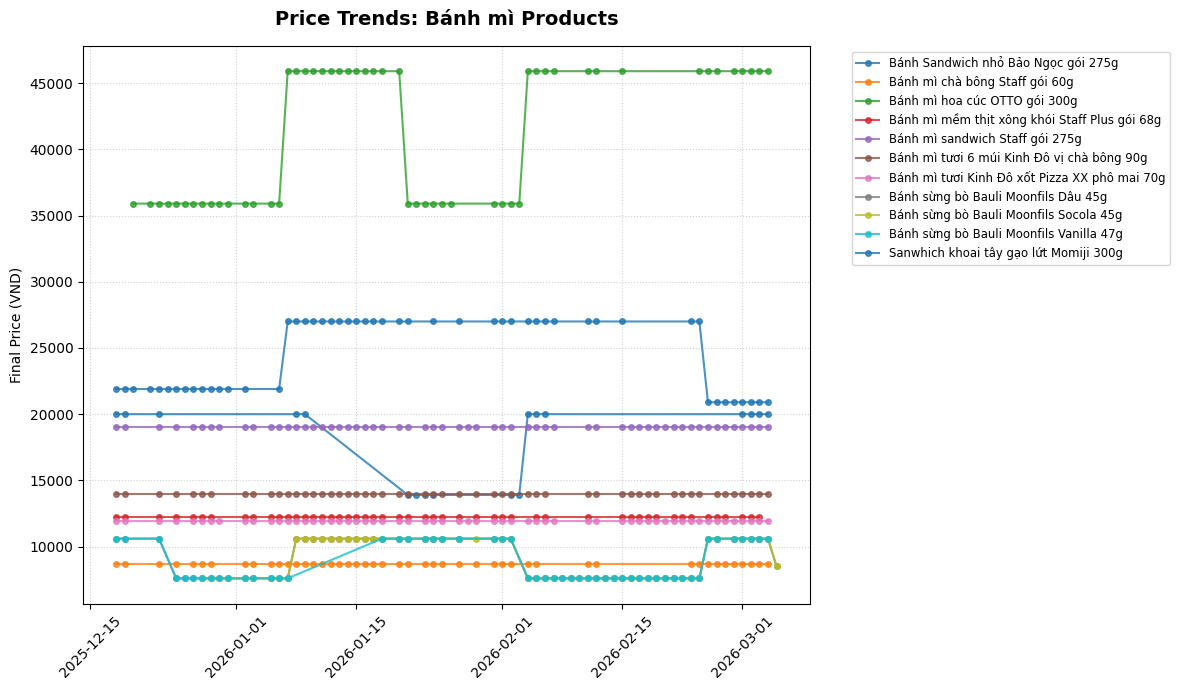

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

# --- Configuration ---
ROOT_DIR = Path('/Users/my/Online Food Price/Processed_food')
LOOKUP_PATH = ROOT_DIR / 'cat_lookup_table.csv'
CSV_DIR = ROOT_DIR / 'CSV'

def process_and_visualize_banh_mi():
    # 1. Load lookup table and identify Bánh mì products
    try:
        lookup_df = pd.read_csv(LOOKUP_PATH)
        # Ensure we capture only the subcategory "Bánh mì"
        banh_mi_names = lookup_df[lookup_df['subcategory'].str.strip() == 'Bánh mì']['product_name'].unique()
        print(f"✅ Found {len(banh_mi_names)} Bánh mì products in lookup table.")
    except Exception as e:
        print(f"❌ Error loading lookup table: {e}")
        return

    # 2. Extract price data from all CSVs in the subfolder
    all_data = []
    for csv_file in CSV_DIR.glob('*.csv'):
        try:
            # Extract date from filename: run_YYYY-MM-DD_...
            # Based on your screenshot: run_2025-12-18_29f58...
            date_str = csv_file.name.split('_')[1]
            
            df = pd.read_csv(csv_file)
            # Filter for the specific product names identified in step 1
            filtered = df[df['product_name'].isin(banh_mi_names)].copy()
            filtered['date'] = pd.to_datetime(date_str)
            
            all_data.append(filtered[['date', 'product_name', 'final_price']])
        except Exception:
            # Skip files that don't match the naming convention or are empty
            continue

    if not all_data:
        print("❌ No matching Banh mi data found in the CSV files.")
        return

    # 3. Consolidate Data
    full_df = pd.concat(all_data).sort_values(['product_name', 'date'])
    
    # 4. Visualization
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Plot a unique line for each Bánh mì product found
    for product in full_df['product_name'].unique():
        product_data = full_df[full_df['product_name'] == product]
        ax.plot(product_data['date'], product_data['final_price'], 
                label=product, marker='o', markersize=4, linewidth=1.5, alpha=0.8)

    # Styling
    ax.set_title('Price Trends: Bánh mì Products', fontsize=14, fontweight='bold', pad=15)
    ax.set_ylabel('Final Price (VND)')
    ax.grid(True, linestyle=':', alpha=0.6)
    
    # Date Formatting
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.xticks(rotation=45)
    
    # Position legend outside to avoid overlap with lines
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    process_and_visualize_banh_mi()

/var/folders/b_/yrldqmrj78q_vxwc52jxhpn80000gn/T/ipykernel_66410/1046238954.py:17: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_raw['date'] = pd.to_datetime(df_raw['scrape_timestamp']).dt.date


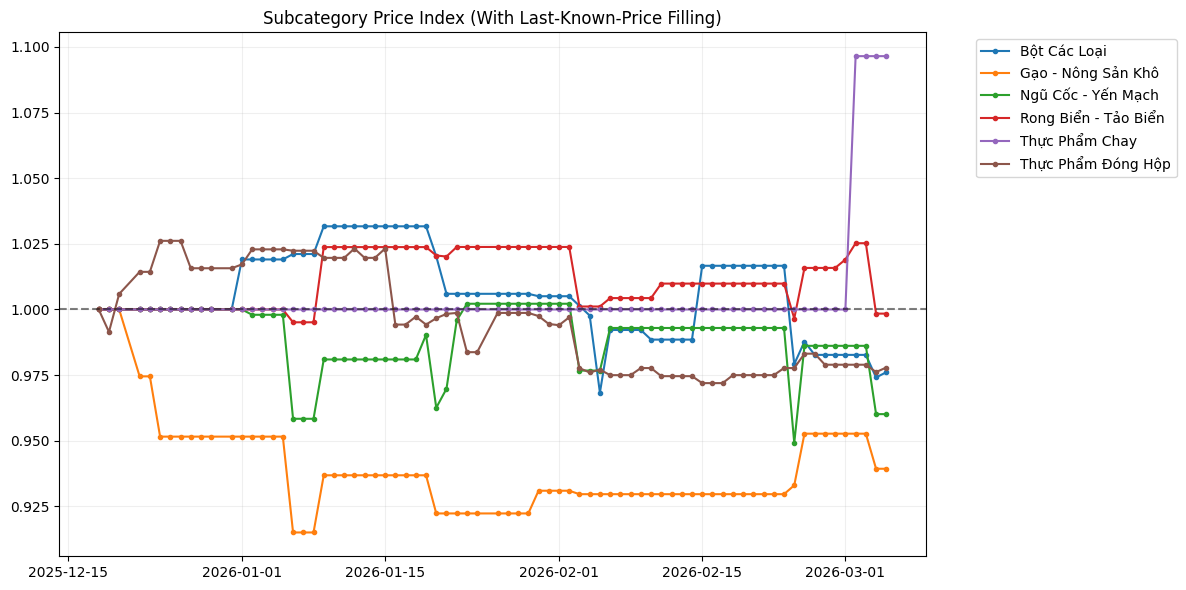

In [5]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt

# 1. Setup & Load
path = './Dry_Food/CSV/' 
lookup_file = './Dry_Food/cat_lookup_table.csv'
all_files = glob.glob(os.path.join(path, "*.csv"))

df_list = [pd.read_csv(f) for f in all_files]
df_raw = pd.concat(df_list, ignore_index=True)
df_lookup = pd.read_csv(lookup_file)
df_lookup.columns = df_lookup.columns.str.strip()

# Clean dates
df_raw['date'] = pd.to_datetime(df_raw['scrape_timestamp']).dt.date
all_dates = sorted(df_raw['date'].unique())
all_products = df_raw['product_name'].unique()

# 2. Create the "Full Grid" (Every product for every date)
multi_index = pd.MultiIndex.from_product([all_dates, all_products], names=['date', 'product_name'])
full_grid = pd.DataFrame(index=multi_index).reset_index()

# 3. Merge Scraped Data into Grid
# We only need product, date, and price for the calculation
df_merged = pd.merge(full_grid, df_raw[['date', 'product_name', 'final_price']], 
                     on=['date', 'product_name'], how='left')

# 4. FORWARD FILL (The magic step)
# Sort by product and date, then fill missing prices with the last known price
df_merged = df_merged.sort_values(['product_name', 'date'])
df_merged['final_price'] = df_merged.groupby('product_name')['final_price'].ffill()

# 5. Bring back Subcategories
df_final = pd.merge(df_merged, df_lookup[['product_name', 'subcategory']], on='product_name', how='left')

# 6. Calculate Index (Benchmark = First Date)
# Drop rows that are still NaN (products that hadn't appeared yet for the first time)
df_final = df_final.dropna(subset=['final_price', 'subcategory'])

daily_avg = df_final.groupby(['date', 'subcategory'], as_index=False)['final_price'].mean()
daily_avg['benchmark'] = daily_avg.groupby('subcategory')['final_price'].transform('first')
daily_avg['price_index'] = daily_avg['final_price'] / daily_avg['benchmark']

# 7. Visualization
plt.figure(figsize=(12, 6))
for subcat in daily_avg['subcategory'].unique():
    subset = daily_avg[daily_avg['subcategory'] == subcat]
    plt.plot(subset['date'], subset['price_index'], marker='.', label=subcat)

plt.axhline(1.0, color='black', linestyle='--', alpha=0.5)
plt.title('Subcategory Price Index (With Last-Known-Price Filling)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

Scanning directories...


/var/folders/b_/yrldqmrj78q_vxwc52jxhpn80000gn/T/ipykernel_66410/2921534279.py:40: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_raw['date'] = pd.to_datetime(df_raw['scrape_timestamp']).dt.date


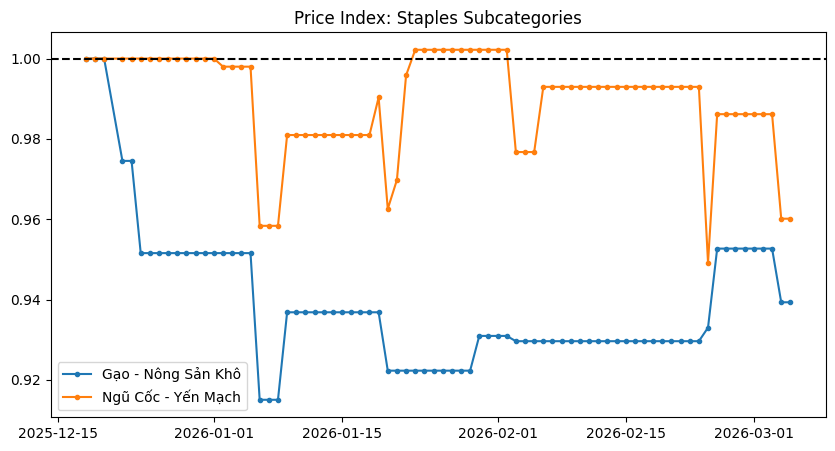

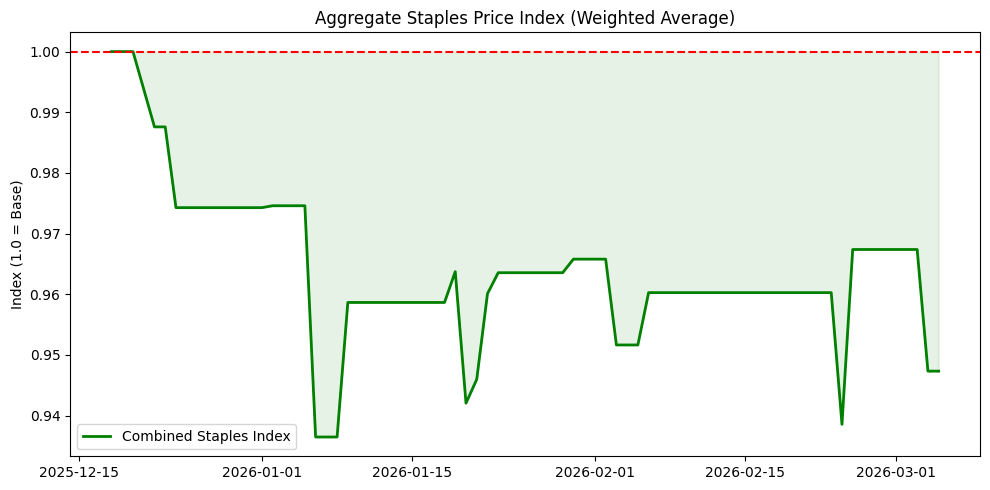

In [6]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt

# 1. Configuration & Path Discovery
# List of all folders identified from your directory structure
folders = [
    'Baby_product', 'Confectionary', 'Dairy', 'Dry_Food', 
    'Egg_and_soy', 'Frozen', 'Instant_food', 'Processed_food', 
    'Spice', 'Veg_Fruit'
]

all_price_data = []
all_lookups = []

print("Scanning directories...")

for folder in folders:
    # Adjust path if script is not in the 'Online Food Price' root
    folder_path = os.path.join('.', folder)
    csv_pattern = os.path.join(folder_path, 'CSV', '*.csv')
    lookup_path = os.path.join(folder_path, 'cat_lookup_table.csv')
    
    # Load Price CSVs
    files = glob.glob(csv_pattern)
    for f in files:
        all_price_data.append(pd.read_csv(f))
        
    # Load Category Lookups
    if os.path.exists(lookup_path):
        all_lookups.append(pd.read_csv(lookup_path))

# Combine all data
df_raw = pd.concat(all_price_data, ignore_index=True)
df_lookup = pd.concat(all_lookups, ignore_index=True).drop_duplicates(subset=['product_name'])
df_lookup.columns = df_lookup.columns.str.strip()

# 2. Date and Product Grid Preparation
df_raw['date'] = pd.to_datetime(df_raw['scrape_timestamp']).dt.date
all_dates = sorted(df_raw['date'].unique())
all_products = df_raw['product_name'].unique()

# Create a full grid to handle missing days
multi_index = pd.MultiIndex.from_product([all_dates, all_products], names=['date', 'product_name'])
full_grid = pd.DataFrame(index=multi_index).reset_index()

# 3. Merge & Forward Fill (Latest Known Price)
df_merged = pd.merge(full_grid, df_raw[['date', 'product_name', 'final_price']], 
                     on=['date', 'product_name'], how='left')

df_merged = df_merged.sort_values(['product_name', 'date'])
df_merged['final_price'] = df_merged.groupby('product_name')['final_price'].ffill()

# Merge categories back in and drop items before their first appearance
df_final = pd.merge(df_merged, df_lookup[['product_name', 'subcategory']], on='product_name', how='left')
df_final = df_final.dropna(subset=['final_price', 'subcategory'])

# 4. Filtering for Staples
# 'Gạo - Nông Sản Khác' and 'Ngũ Cốc - Yến Mạch'
staple_subcats = ['Gạo - Nông Sản Khô', 'Ngũ Cốc - Yến Mạch']
df_staples = df_final[df_final['subcategory'].isin(staple_subcats)]

# --- VIZ 1: Staples by Subcategory ---
daily_subcat = df_staples.groupby(['date', 'subcategory'], as_index=False)['final_price'].mean()
daily_subcat['idx'] = daily_subcat.groupby('subcategory')['final_price'].transform(lambda x: x / x.iloc[0])

plt.figure(figsize=(10, 5))
for sub in daily_subcat['subcategory'].unique():
    data = daily_subcat[daily_subcat['subcategory'] == sub]
    plt.plot(data['date'], data['idx'], marker='.', label=sub)
plt.axhline(1, color='black', ls='--')
plt.title("Price Index: Staples Subcategories")
plt.legend()
plt.show()

# --- VIZ 2: Index of Averaged Staples (Aggregate) ---
daily_total = df_staples.groupby('date', as_index=False)['final_price'].mean()
daily_total['staples_index'] = daily_total['final_price'] / daily_total['final_price'].iloc[0]

plt.figure(figsize=(10, 5))
plt.plot(daily_total['date'], daily_total['staples_index'], color='green', linewidth=2, label='Combined Staples Index')
plt.fill_between(daily_total['date'], 1, daily_total['staples_index'], color='green', alpha=0.1)
plt.axhline(1, color='red', ls='--')
plt.title("Aggregate Staples Price Index (Weighted Average)")
plt.ylabel("Index (1.0 = Base)")
plt.legend()
plt.tight_layout()
plt.show()

/var/folders/b_/yrldqmrj78q_vxwc52jxhpn80000gn/T/ipykernel_66410/2921376996.py:36: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_raw['date'] = pd.to_datetime(df_raw['scrape_timestamp']).dt.date


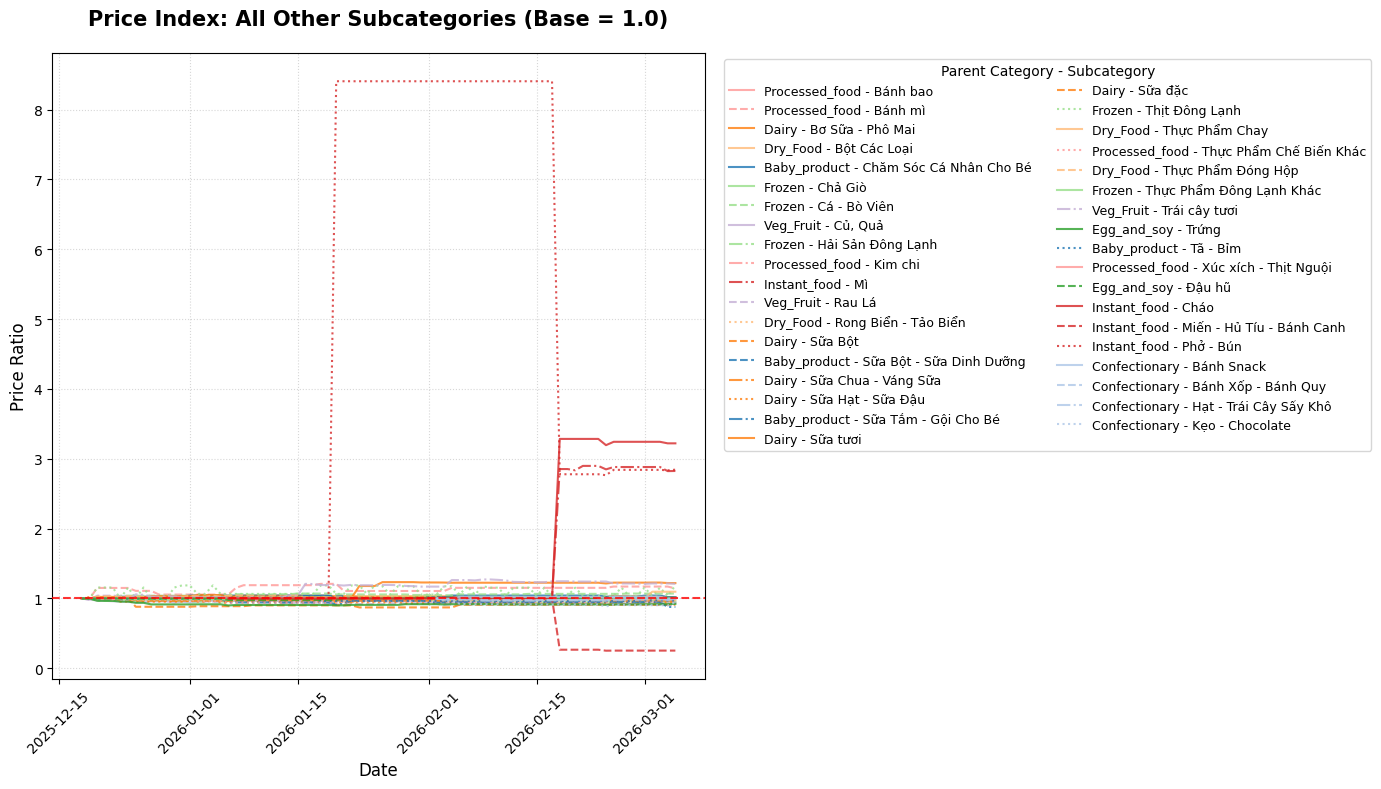

In [7]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. Global Setup
folders = [
    'Baby_product', 'Confectionary', 'Dairy', 'Dry_Food', 
    'Egg_and_soy', 'Frozen', 'Instant_food', 'Processed_food', 
    'Spice', 'Veg_Fruit'
]

all_price_data = []
all_lookups = []

for folder in folders:
    csv_pattern = os.path.join(folder, 'CSV', '*.csv')
    lookup_path = os.path.join(folder, 'cat_lookup_table.csv')
    
    files = glob.glob(csv_pattern)
    for f in files:
        all_price_data.append(pd.read_csv(f))
        
    if os.path.exists(lookup_path):
        df_lkp = pd.read_csv(lookup_path)
        df_lkp.columns = df_lkp.columns.str.strip()
        # Added: Track the parent folder in the lookup table as a fallback
        df_lkp['parent_category'] = folder 
        all_lookups.append(df_lkp)

df_raw = pd.concat(all_price_data, ignore_index=True)
df_lookup = pd.concat(all_lookups, ignore_index=True).drop_duplicates(subset=['product_name'])

# 2. Preparation & Forward Fill Logic
df_raw['date'] = pd.to_datetime(df_raw['scrape_timestamp']).dt.date
all_dates = sorted(df_raw['date'].unique())
all_products = df_raw['product_name'].unique()

multi_index = pd.MultiIndex.from_product([all_dates, all_products], names=['date', 'product_name'])
full_grid = pd.DataFrame(index=multi_index).reset_index()

df_merged = pd.merge(full_grid, df_raw[['date', 'product_name', 'final_price']], on=['date', 'product_name'], how='left')
df_merged = df_merged.sort_values(['product_name', 'date'])
df_merged['final_price'] = df_merged.groupby('product_name')['final_price'].ffill()

# Added: Include 'parent_category' in the merge so it travels to the final dataset
df_final = pd.merge(df_merged, df_lookup[['product_name', 'subcategory', 'parent_category']], on='product_name', how='left')
df_final = df_final.dropna(subset=['final_price', 'subcategory', 'parent_category'])

# 3. Filtering OUT Staples to see "Everything Else"
staple_names = ['Gạo - Nông Sản Khô', 'Ngũ Cốc - Yến Mạch']
df_others = df_final[~df_final['subcategory'].isin(staple_names)]

# 4. Calculation
# Added: Include 'parent_category' in the groupby to retain it for the plotting phase
daily_subcat = df_others.groupby(['date', 'subcategory', 'parent_category'], as_index=False)['final_price'].mean()
daily_subcat['index'] = daily_subcat.groupby('subcategory')['final_price'].transform(lambda x: x / x.iloc[0])

# 5. Visualization using the Global Style Manager
plt.figure(figsize=(14, 8))
subcategories = daily_subcat['subcategory'].unique()

for sub in subcategories:
    subset = daily_subcat[daily_subcat['subcategory'] == sub]
    if subset.empty:
        continue
        
    # Query the global style manager
    # Note: style_config must be initialized in your Jupyter notebook before running this cell
    style_info = style_config.get_style(sub)
    
    # Determine the parent name, utilizing the fallback if it's 'Unknown' in the manager
    parent_name = style_info['parent']
    if parent_name == 'Unknown':
        parent_name = subset['parent_category'].iloc[0]
        
    plot_color = style_info['color']
    plot_style = style_info['linestyle']
    
    plt.plot(subset['date'], subset['index'], 
             label=f"{parent_name} - {sub}", 
             color=plot_color, 
             linestyle=plot_style, 
             alpha=0.8, 
             linewidth=1.5)

# Styling
plt.axhline(1.0, color='red', linestyle='--', linewidth=1.5, alpha=0.8, zorder=5) # Matches baseline style of other charts
plt.title("Price Index: All Other Subcategories (Base = 1.0)", fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price Ratio", fontsize=12)

# Legend adjustments to handle formatted names
plt.legend(title="Parent Category - Subcategory", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9, ncol=2)
plt.grid(True, which='both', linestyle=':', alpha=0.5)

# Formatting dates
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [8]:
import pandas as pd
import glob
import os

# 1. Standard Global Data Load (matching your previous structure)
folders = ['Baby_product', 'Confectionary', 'Dairy', 'Dry_Food', 'Egg_and_soy', 
           'Frozen', 'Instant_food', 'Processed_food', 'Spice', 'Veg_Fruit']

all_price_data, all_lookups = [], []
for folder in folders:
    csv_pattern, lookup_path = os.path.join(folder, 'CSV', '*.csv'), os.path.join(folder, 'cat_lookup_table.csv')
    files = glob.glob(csv_pattern)
    for f in files: all_price_data.append(pd.read_csv(f))
    if os.path.exists(lookup_path):
        df_lkp = pd.read_csv(lookup_path)
        df_lkp.columns = df_lkp.columns.str.strip()
        all_lookups.append(df_lkp)

df_raw = pd.concat(all_price_data, ignore_index=True)
df_lookup = pd.concat(all_lookups, ignore_index=True).drop_duplicates(subset=['product_name'])

# 2. Forward Fill & Index Calculation
df_raw['date'] = pd.to_datetime(df_raw['scrape_timestamp']).dt.date
all_dates, all_products = sorted(df_raw['date'].unique()), df_raw['product_name'].unique()
multi_index = pd.MultiIndex.from_product([all_dates, all_products], names=['date', 'product_name'])
full_grid = pd.DataFrame(index=multi_index).reset_index()

df_filled = pd.merge(full_grid, df_raw[['date', 'product_name', 'final_price']], on=['date', 'product_name'], how='left')
df_filled = df_filled.sort_values(['product_name', 'date'])
df_filled['final_price'] = df_filled.groupby('product_name')['final_price'].ffill()

df_final = pd.merge(df_filled, df_lookup[['product_name', 'subcategory']], on='product_name', how='left').dropna()

# 3. Detect Outliers
daily_subcat = df_final.groupby(['date', 'subcategory'], as_index=False)['final_price'].mean()
daily_subcat['index'] = daily_subcat.groupby('subcategory')['final_price'].transform(lambda x: x / x.iloc[0])

# Calculate Max Rise and Max Fall per subcategory
outlier_report = daily_subcat.groupby('subcategory')['index'].agg(['max', 'min']).reset_index()
outlier_report.columns = ['Subcategory', 'Peak_Ratio', 'Trough_Ratio']

# Thresholds: Rise > 50% (1.5) or Fall > 30% (0.7)
major_rises = outlier_report[outlier_report['Peak_Ratio'] > 1.5].sort_values(by='Peak_Ratio', ascending=False)
major_falls = outlier_report[outlier_report['Trough_Ratio'] < 0.7].sort_index()

print("--- SUBSTANTIAL RISES (Outliers) ---")
print(major_rises)
print("\n--- SUBSTANTIAL FALLS (Outliers) ---")
print(major_falls)

/var/folders/b_/yrldqmrj78q_vxwc52jxhpn80000gn/T/ipykernel_66410/1402338082.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_raw['date'] = pd.to_datetime(df_raw['scrape_timestamp']).dt.date


--- SUBSTANTIAL RISES (Outliers) ---
   Subcategory  Peak_Ratio  Trough_Ratio
19   Phở - Bún    8.407018           1.0
6         Cháo    3.284848           1.0
17          Mì    2.898460           1.0

--- SUBSTANTIAL FALLS (Outliers) ---
                  Subcategory  Peak_Ratio  Trough_Ratio
16  Miến - Hủ Tíu - Bánh Canh         1.0      0.251938


To investigate those massive swings in categories like **Phở - Bún (the $8.4$x rise)** and **Miến - Hủ Tíu - Bánh Canh (the $0.25$x fall)**, we need to look at the individual product price ratios within those specific subcategories.

/var/folders/b_/yrldqmrj78q_vxwc52jxhpn80000gn/T/ipykernel_66410/938152629.py:31: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_raw['date'] = pd.to_datetime(df_raw['scrape_timestamp']).dt.date


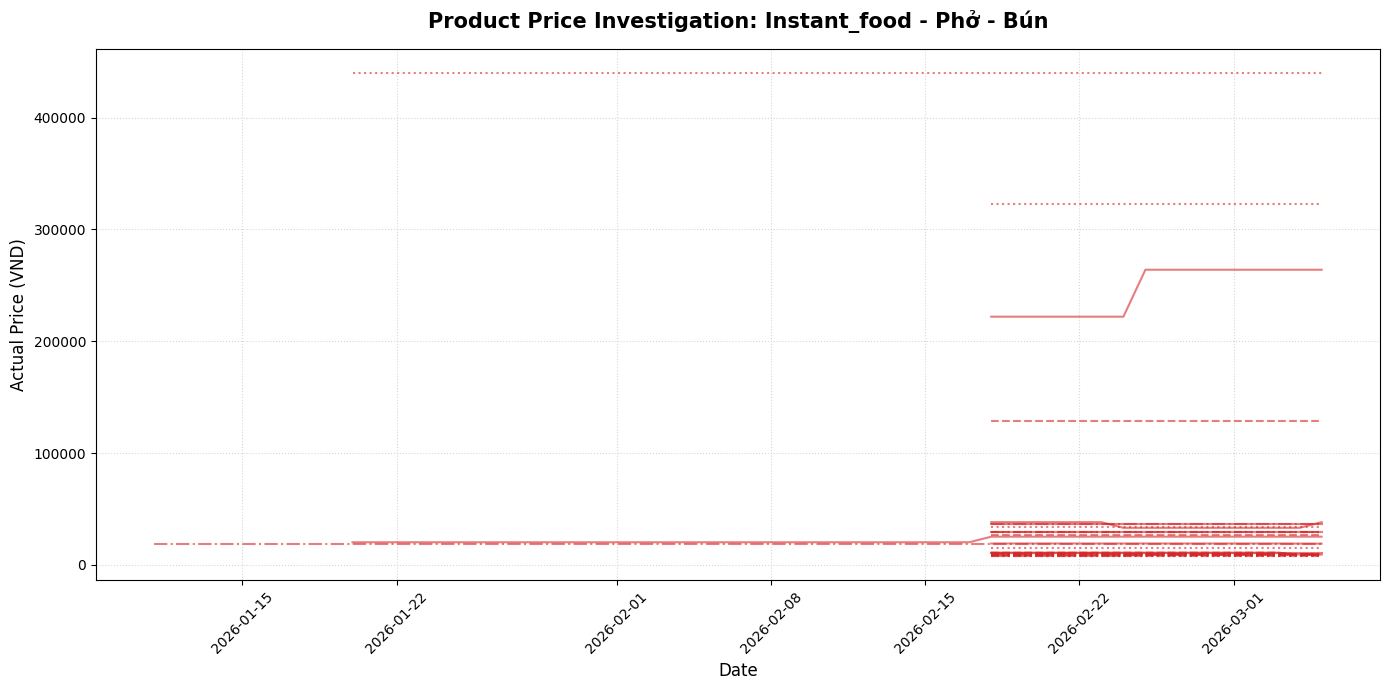

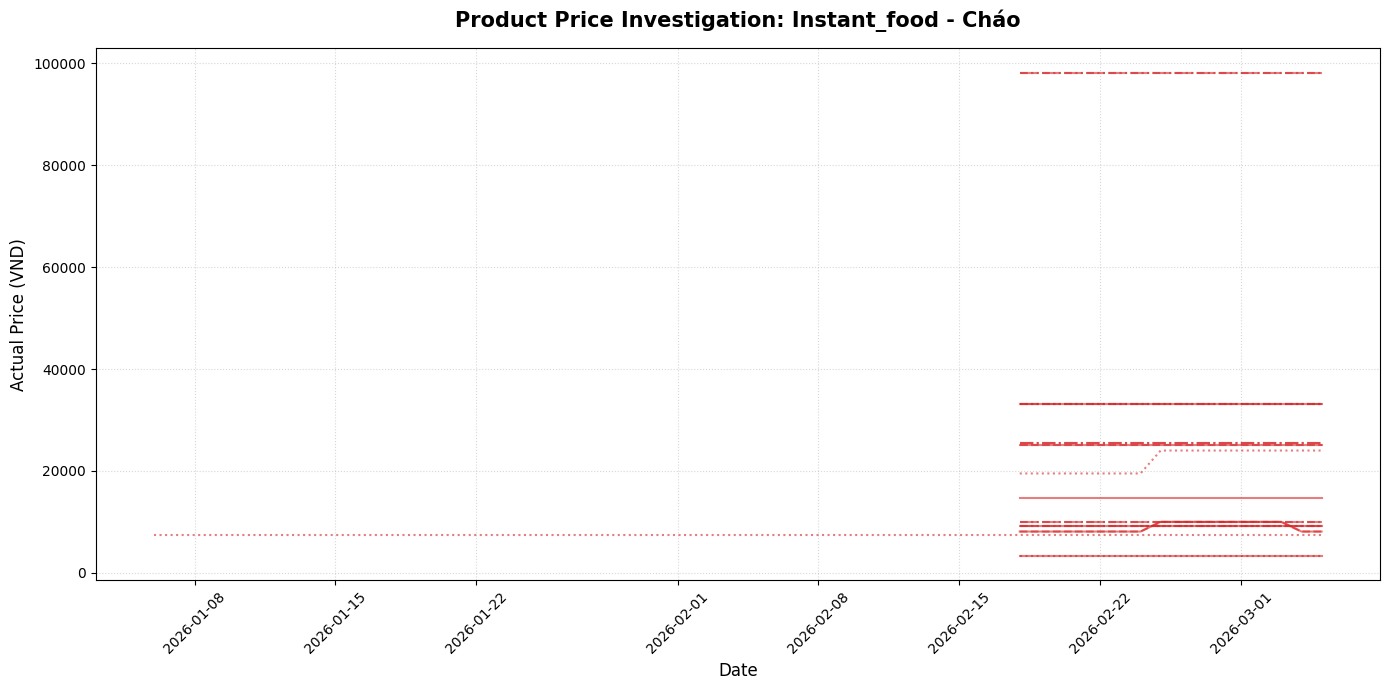

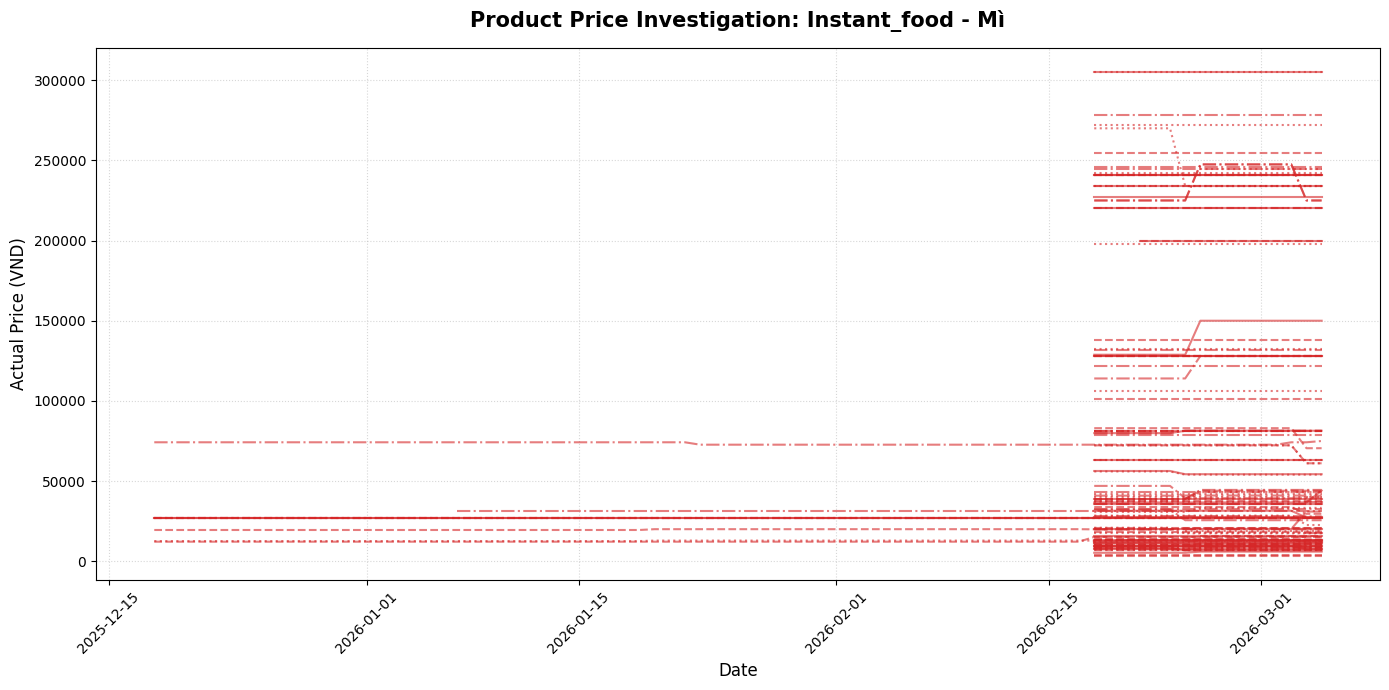

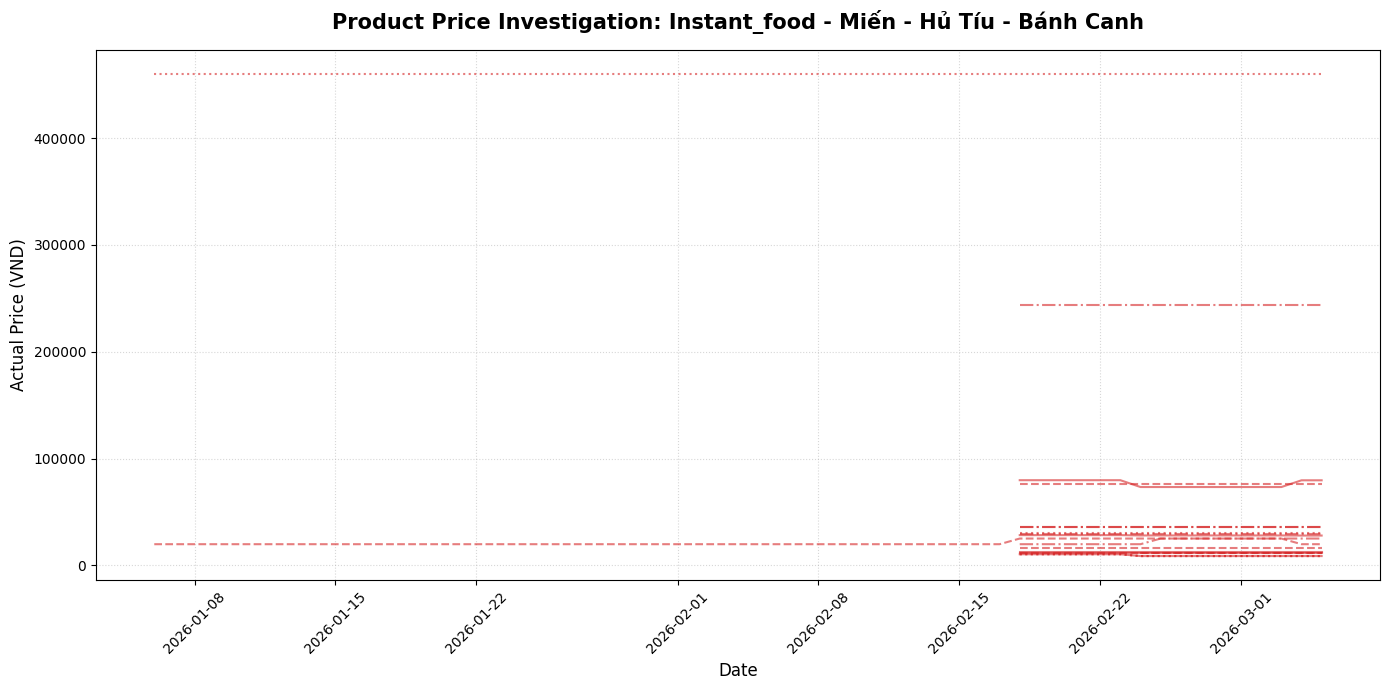

In [9]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. Global Setup & Discovery
folders = ['Baby_product', 'Confectionary', 'Dairy', 'Dry_Food', 'Egg_and_soy', 
           'Frozen', 'Instant_food', 'Processed_food', 'Spice', 'Veg_Fruit']

all_price_data, all_lookups = [], []

for folder in folders:
    csv_pattern = os.path.join(folder, 'CSV', '*.csv')
    lookup_path = os.path.join(folder, 'cat_lookup_table.csv')
    
    files = glob.glob(csv_pattern)
    for f in files: all_price_data.append(pd.read_csv(f))
    
    if os.path.exists(lookup_path):
        df_lkp = pd.read_csv(lookup_path)
        df_lkp.columns = df_lkp.columns.str.strip()
        # Added: Track the parent folder in the lookup table as a fallback
        df_lkp['parent_category'] = folder 
        all_lookups.append(df_lkp)

df_raw = pd.concat(all_price_data, ignore_index=True)
df_lookup = pd.concat(all_lookups, ignore_index=True).drop_duplicates(subset=['product_name'])

# 2. Date Cleaning & Forward Fill (Last Known Price)
df_raw['date'] = pd.to_datetime(df_raw['scrape_timestamp']).dt.date
all_dates = sorted(df_raw['date'].unique())
all_products = df_raw['product_name'].unique()

multi_index = pd.MultiIndex.from_product([all_dates, all_products], names=['date', 'product_name'])
full_grid = pd.DataFrame(index=multi_index).reset_index()

df_filled = pd.merge(full_grid, df_raw[['date', 'product_name', 'final_price']], on=['date', 'product_name'], how='left')
df_filled = df_filled.sort_values(['product_name', 'date'])
df_filled['final_price'] = df_filled.groupby('product_name')['final_price'].ffill()

# Re-link subcategories AND parent categories
df_final = pd.merge(df_filled, df_lookup[['product_name', 'subcategory', 'parent_category']], on='product_name', how='left').dropna()

# 3. Define Target Outliers for Investigation
outlier_subcats = ['Phở - Bún', 'Cháo', 'Mì', 'Miến - Hủ Tíu - Bánh Canh']

# 4. Visualization: Product-Level Investigation
for subcat in outlier_subcats:
    plt.figure(figsize=(14, 7)) # Widened slightly to accommodate the legend
    subset = df_final[df_final['subcategory'] == subcat]
    
    if subset.empty:
        print(f"⚠️ No data found for {subcat}")
        continue
        
    # Fetch the global style for this subcategory
    # Note: style_config must be initialized in your Jupyter notebook before running this
    style_info = style_config.get_style(subcat)
    parent_name = style_info['parent']
    if parent_name == 'Unknown':
        parent_name = subset['parent_category'].iloc[0]
    
    plot_color = style_info['color']
    
    # We rotate linestyles to help differentiate individual products 
    # while keeping the shared categorical color scheme
    line_styles = ['-', '--', '-.', ':']
    unique_products = subset['product_name'].unique()
    
    for i, product in enumerate(unique_products):
        prod_data = subset[subset['product_name'] == product]
        current_style = line_styles[i % len(line_styles)]
        
        plt.plot(prod_data['date'], prod_data['final_price'], 
                 label=product[:40] + ("..." if len(product) > 40 else ""), 
                 color=plot_color, 
                 linestyle=current_style,
                 alpha=0.6, 
                 linewidth=1.5)

    # Styling
    plt.title(f'Product Price Investigation: {parent_name} - {subcat}', fontsize=15, fontweight='bold', pad=15)
    plt.ylabel('Actual Price (VND)', fontsize=12)
    plt.xlabel('Date', fontsize=12)
    
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.xticks(rotation=45)
    plt.grid(True, linestyle=':', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

/var/folders/b_/yrldqmrj78q_vxwc52jxhpn80000gn/T/ipykernel_66410/580709143.py:36: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_raw['date'] = pd.to_datetime(df_raw['scrape_timestamp']).dt.date


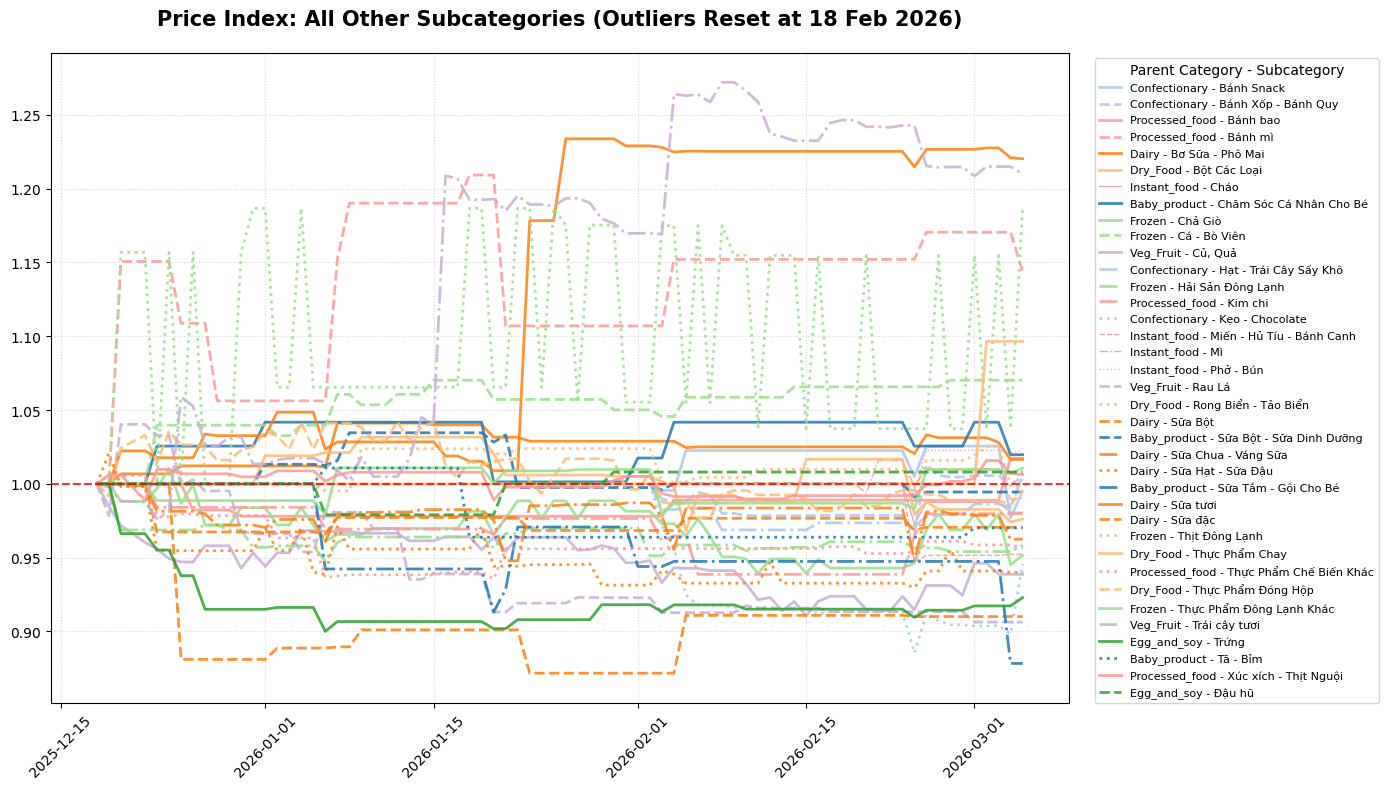

/var/folders/b_/yrldqmrj78q_vxwc52jxhpn80000gn/T/ipykernel_66410/580709143.py:116: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=subcat_stats.sort_values('product_count', ascending=False),
/var/folders/b_/yrldqmrj78q_vxwc52jxhpn80000gn/T/ipykernel_66410/580709143.py:123: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=subcat_stats.sort_values('volatility', ascending=False),


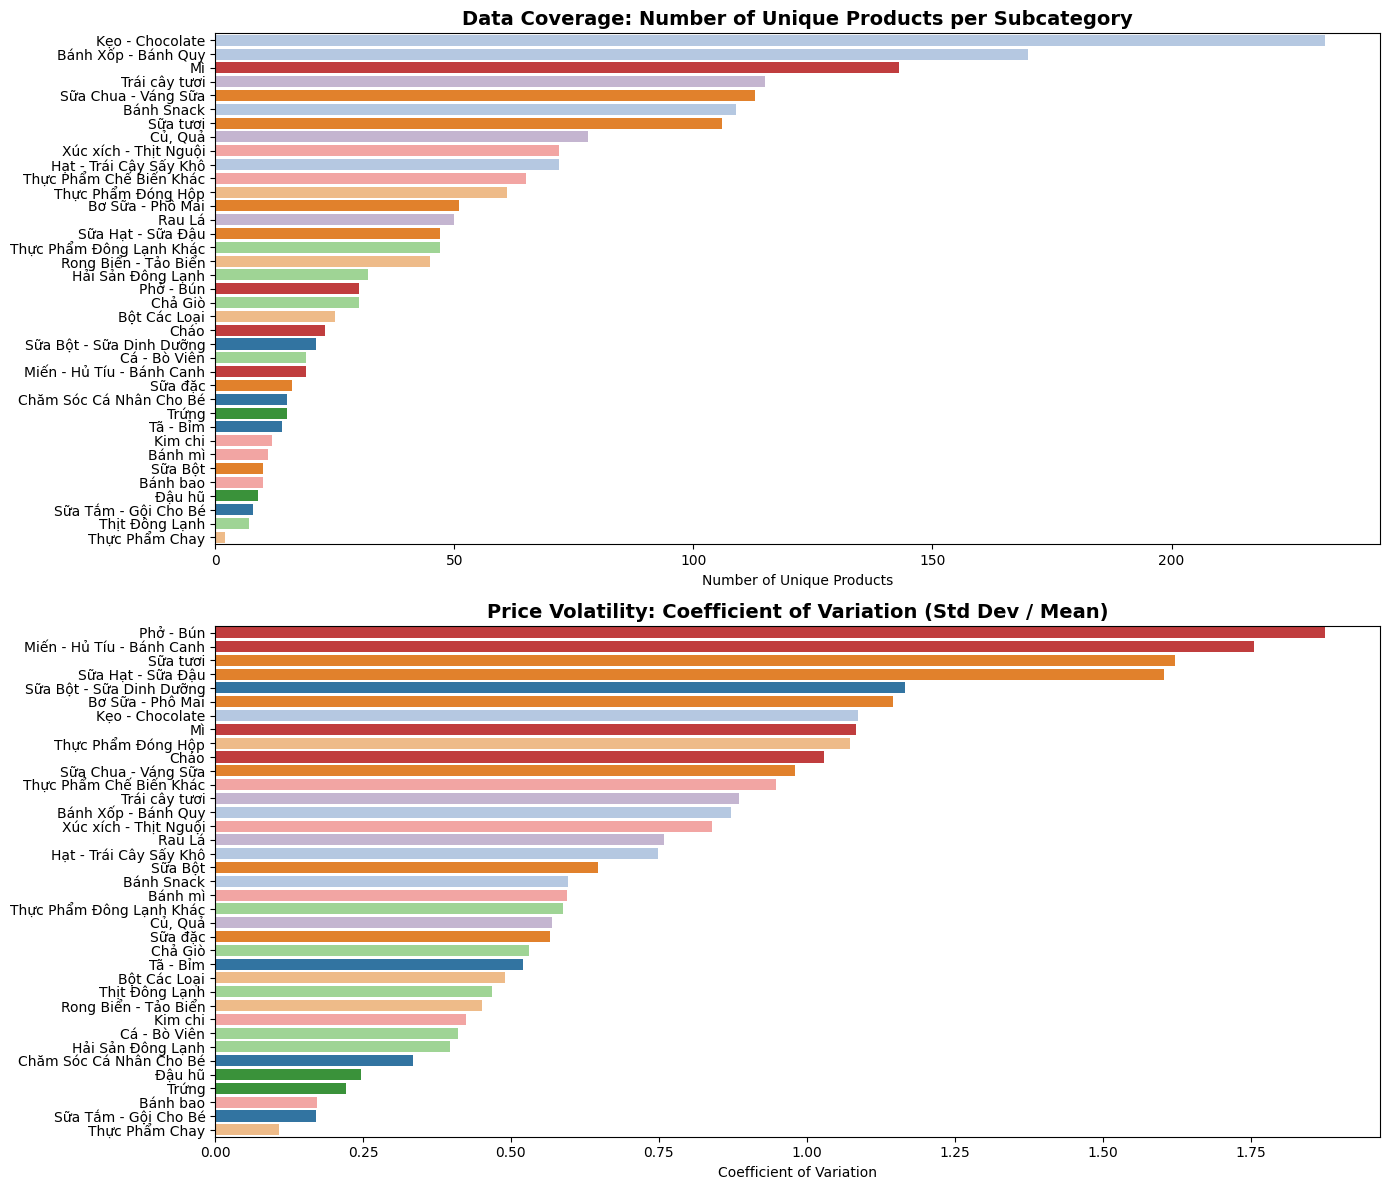

/var/folders/b_/yrldqmrj78q_vxwc52jxhpn80000gn/T/ipykernel_66410/580709143.py:142: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


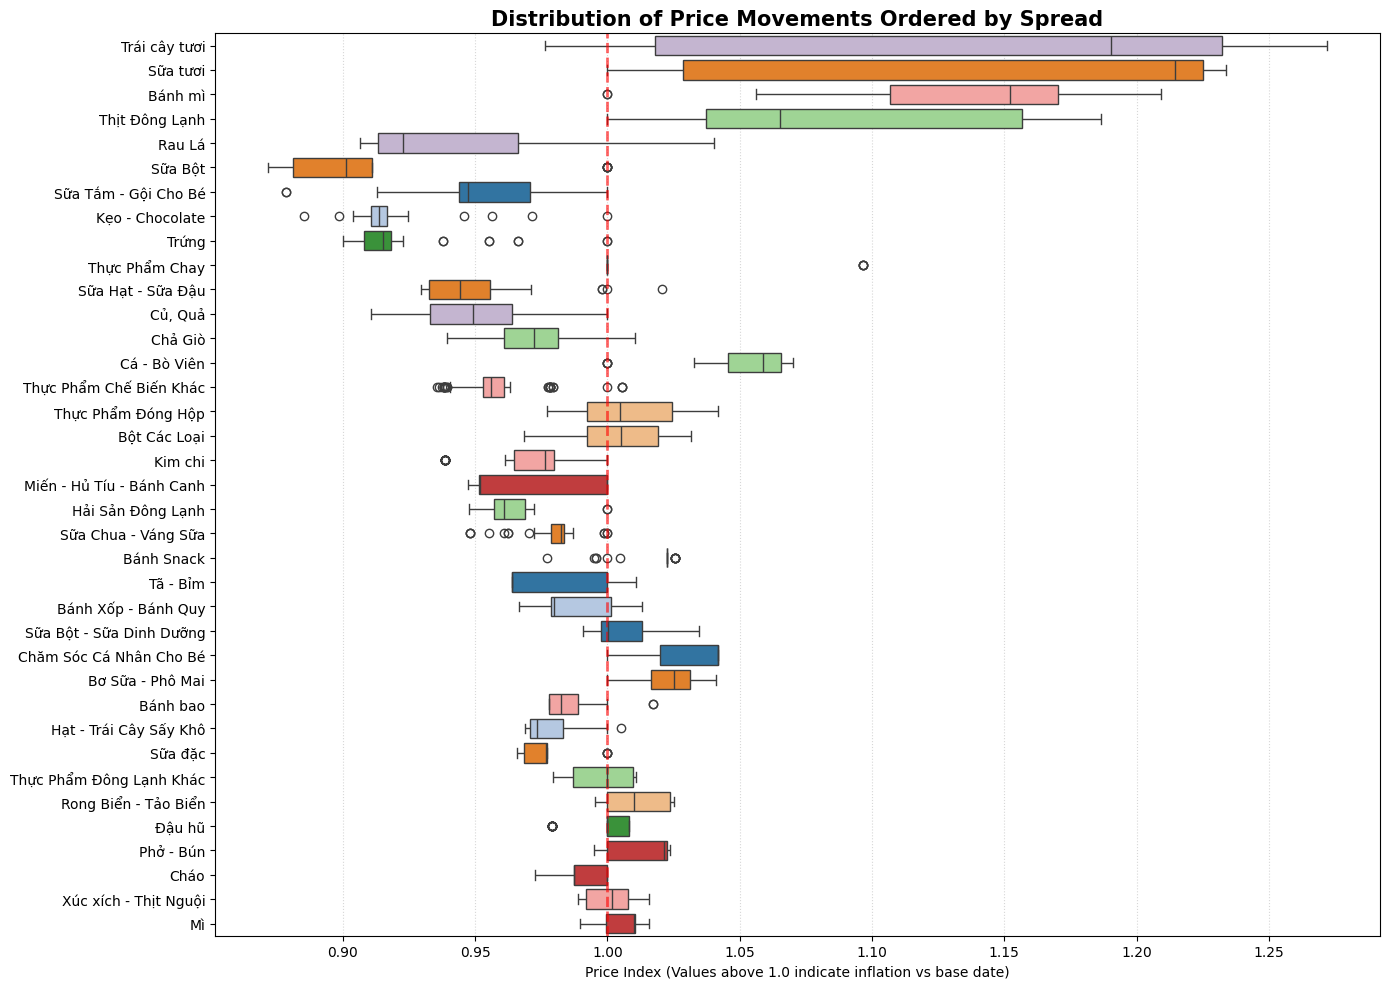


--- Statistical Data Summary ---
              subcategory  product_count    mean_price     std_price  volatility
                Phở - Bún             30  53448.541667 100221.619757    1.875105
Miến - Hủ Tíu - Bánh Canh             19  61841.946309 108596.317094    1.756030
                 Sữa tươi            106  60591.702342  98258.551586    1.621650
        Sữa Hạt - Sữa Đậu             47  94919.694019 152226.830177    1.603743
 Sữa Bột - Sữa Dinh Dưỡng             21 150825.837018 175826.907782    1.165761
         Bơ Sữa - Phô Mai             51 113365.413149 129936.538151    1.146174
          Kẹo - Chocolate            232  57475.274424  62476.892327    1.087022
                       Mì            143  80831.882086  87508.454268    1.082598
       Thực Phẩm Đóng Hộp             61  61067.959313  65507.938475    1.072706
                     Cháo             23  24395.303867  25106.271745    1.029144
      Sữa Chua - Váng Sữa            113  40512.304484  39715.370193    0.9

In [10]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# 1. Global Setup
folders = [
    'Baby_product', 'Confectionary', 'Dairy', 'Dry_Food', 
    'Egg_and_soy', 'Frozen', 'Instant_food', 'Processed_food', 
    'Spice', 'Veg_Fruit'
]

all_price_data = []
all_lookups = []

for folder in folders:
    csv_pattern = os.path.join(folder, 'CSV', '*.csv')
    lookup_path = os.path.join(folder, 'cat_lookup_table.csv')
    
    files = glob.glob(csv_pattern)
    for f in files:
        all_price_data.append(pd.read_csv(f))
        
    if os.path.exists(lookup_path):
        df_lkp = pd.read_csv(lookup_path)
        df_lkp.columns = df_lkp.columns.str.strip()
        df_lkp['parent_category'] = folder 
        all_lookups.append(df_lkp)

df_raw = pd.concat(all_price_data, ignore_index=True)
df_lookup = pd.concat(all_lookups, ignore_index=True).drop_duplicates(subset=['product_name'])

# 2. Preparation & Forward Fill Logic
df_raw['date'] = pd.to_datetime(df_raw['scrape_timestamp']).dt.date
all_dates = sorted(df_raw['date'].unique())
all_products = df_raw['product_name'].unique()

multi_index = pd.MultiIndex.from_product([all_dates, all_products], names=['date', 'product_name'])
full_grid = pd.DataFrame(index=multi_index).reset_index()

df_merged = pd.merge(full_grid, df_raw[['date', 'product_name', 'final_price']], on=['date', 'product_name'], how='left')
df_merged = df_merged.sort_values(['product_name', 'date'])
df_merged['final_price'] = df_merged.groupby('product_name')['final_price'].ffill()

df_final = pd.merge(df_merged, df_lookup[['product_name', 'subcategory', 'parent_category']], on='product_name', how='left')
df_final = df_final.dropna(subset=['final_price', 'subcategory', 'parent_category'])

# 3. Filtering and Outlier Handling
staple_names = ['Gạo - Nông Sản Khô', 'Ngũ Cốc - Yến Mạch']
outlier_subcats = ['Phở - Bún', 'Cháo', 'Mì', 'Miến - Hủ Tíu - Bánh Canh']
cutoff_date = pd.to_datetime('2026-02-18').date()

df_others = df_final[~df_final['subcategory'].isin(staple_names)].copy()
df_others = df_others[~((df_others['subcategory'].isin(outlier_subcats)) & (df_others['date'] < cutoff_date))]

# 4. Calculation
daily_subcat = df_others.sort_values('date').groupby(['date', 'subcategory', 'parent_category'], as_index=False)['final_price'].mean()
daily_subcat['index'] = daily_subcat.groupby('subcategory')['final_price'].transform(lambda x: x / x.iloc[0])

# --- Generate Custom Seaborn Palette from Style Manager ---
subcat_palette = {}
for sub in df_others['subcategory'].unique():
    # Note: style_config must be initialized in your Jupyter notebook before running this
    style_info = style_config.get_style(sub)
    subcat_palette[sub] = style_info['color']

# --- VIZ 1: Price Index Trend (Styled) ---
plt.figure(figsize=(14, 8))
subcategories = sorted(daily_subcat['subcategory'].unique())

for sub in subcategories:
    subset = daily_subcat[daily_subcat['subcategory'] == sub]
    if subset.empty: continue
        
    style_info = style_config.get_style(sub)
    parent_name = style_info['parent']
    if parent_name == 'Unknown':
        parent_name = subset['parent_category'].iloc[0]
        
    plot_color = style_info['color']
    plot_style = style_info['linestyle']
    
    # --- UPDATED: Lowered visual weights for reset subcategories ---
    lw = 1.0 if sub in outlier_subcats else 2.0
    alpha = 0.4 if sub in outlier_subcats else 0.85
    zorder = 1 if sub in outlier_subcats else 5
    
    plt.plot(subset['date'], subset['index'], 
             label=f"{parent_name} - {sub}", 
             color=plot_color, linestyle=plot_style, 
             alpha=alpha, linewidth=lw, zorder=zorder)

plt.axhline(1, color='red', linestyle='--', linewidth=1.5, alpha=0.8, zorder=10) # Put baseline on top
plt.title("Price Index: All Other Subcategories (Outliers Reset at 18 Feb 2026)", fontsize=15, fontweight='bold', pad=20)
plt.legend(title="Parent Category - Subcategory", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.grid(True, which='both', linestyle=':', alpha=0.5)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- VIZ 2: STATISTICAL CHARACTERISTICS ---
subcat_stats = df_others.groupby('subcategory').agg({
    'product_name': 'nunique',
    'final_price': ['mean', 'std']
}).reset_index()
subcat_stats.columns = ['subcategory', 'product_count', 'mean_price', 'std_price']
subcat_stats['volatility'] = subcat_stats['std_price'] / subcat_stats['mean_price']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

# Chart A: Sample Size
sns.barplot(data=subcat_stats.sort_values('product_count', ascending=False), 
            x='product_count', y='subcategory', ax=ax1, palette=subcat_palette)
ax1.set_title('Data Coverage: Number of Unique Products per Subcategory', fontsize=14, fontweight='bold')
ax1.set_xlabel('Number of Unique Products')
ax1.set_ylabel('')

# Chart B: Relative Volatility 
sns.barplot(data=subcat_stats.sort_values('volatility', ascending=False), 
            x='volatility', y='subcategory', ax=ax2, palette=subcat_palette)
ax2.set_title('Price Volatility: Coefficient of Variation (Std Dev / Mean)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Coefficient of Variation')
ax2.set_ylabel('')

plt.tight_layout()
plt.show()

# --- VIZ 3: DISTRIBUTION SPREAD (Boxplot) ---
plt.figure(figsize=(14, 10))

# 1. Calculate the total range (max - min) for each subcategory
range_metrics = daily_subcat.groupby('subcategory')['index'].agg(lambda x: x.max() - x.min())

# 2. Sort them from largest range to smallest range and extract the names
ordered_subcats = range_metrics.sort_values(ascending=False).index.tolist()

# 3. Pass the ordered list to the 'order' parameter
sns.boxplot(
    data=daily_subcat, 
    x='index', 
    y='subcategory', 
    palette=subcat_palette,
    order=ordered_subcats # <--- Added ordering here
)

plt.axvline(1, color='red', linestyle='--', alpha=0.6, linewidth=2)
plt.title('Distribution of Price Movements Ordered by Spread', fontsize=15, fontweight='bold')
plt.xlabel('Price Index (Values above 1.0 indicate inflation vs base date)')
plt.ylabel('')
plt.grid(axis='x', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

# Print a text description summary
print("\n--- Statistical Data Summary ---")
print(subcat_stats.sort_values('volatility', ascending=False).to_string(index=False))

What this grouping shows you:
Group 1 (Usually Deflationary/Discounted): Categories that have generally trended downward or stayed below the 1.0 line.

Group 2 (Stable): The "Control Group." These are your most predictable categories with almost no movement.

Group 3 (Rising/Inflationary): These categories are showing a steady creep upward.

Group 4 (Volatile/Spiky): These often contain the items with the most aggressive promotional cycles (the "sawtooth" pattern).

/var/folders/b_/yrldqmrj78q_vxwc52jxhpn80000gn/T/ipykernel_66410/4207206766.py:37: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_raw['date'] = pd.to_datetime(df_raw['scrape_timestamp']).dt.date


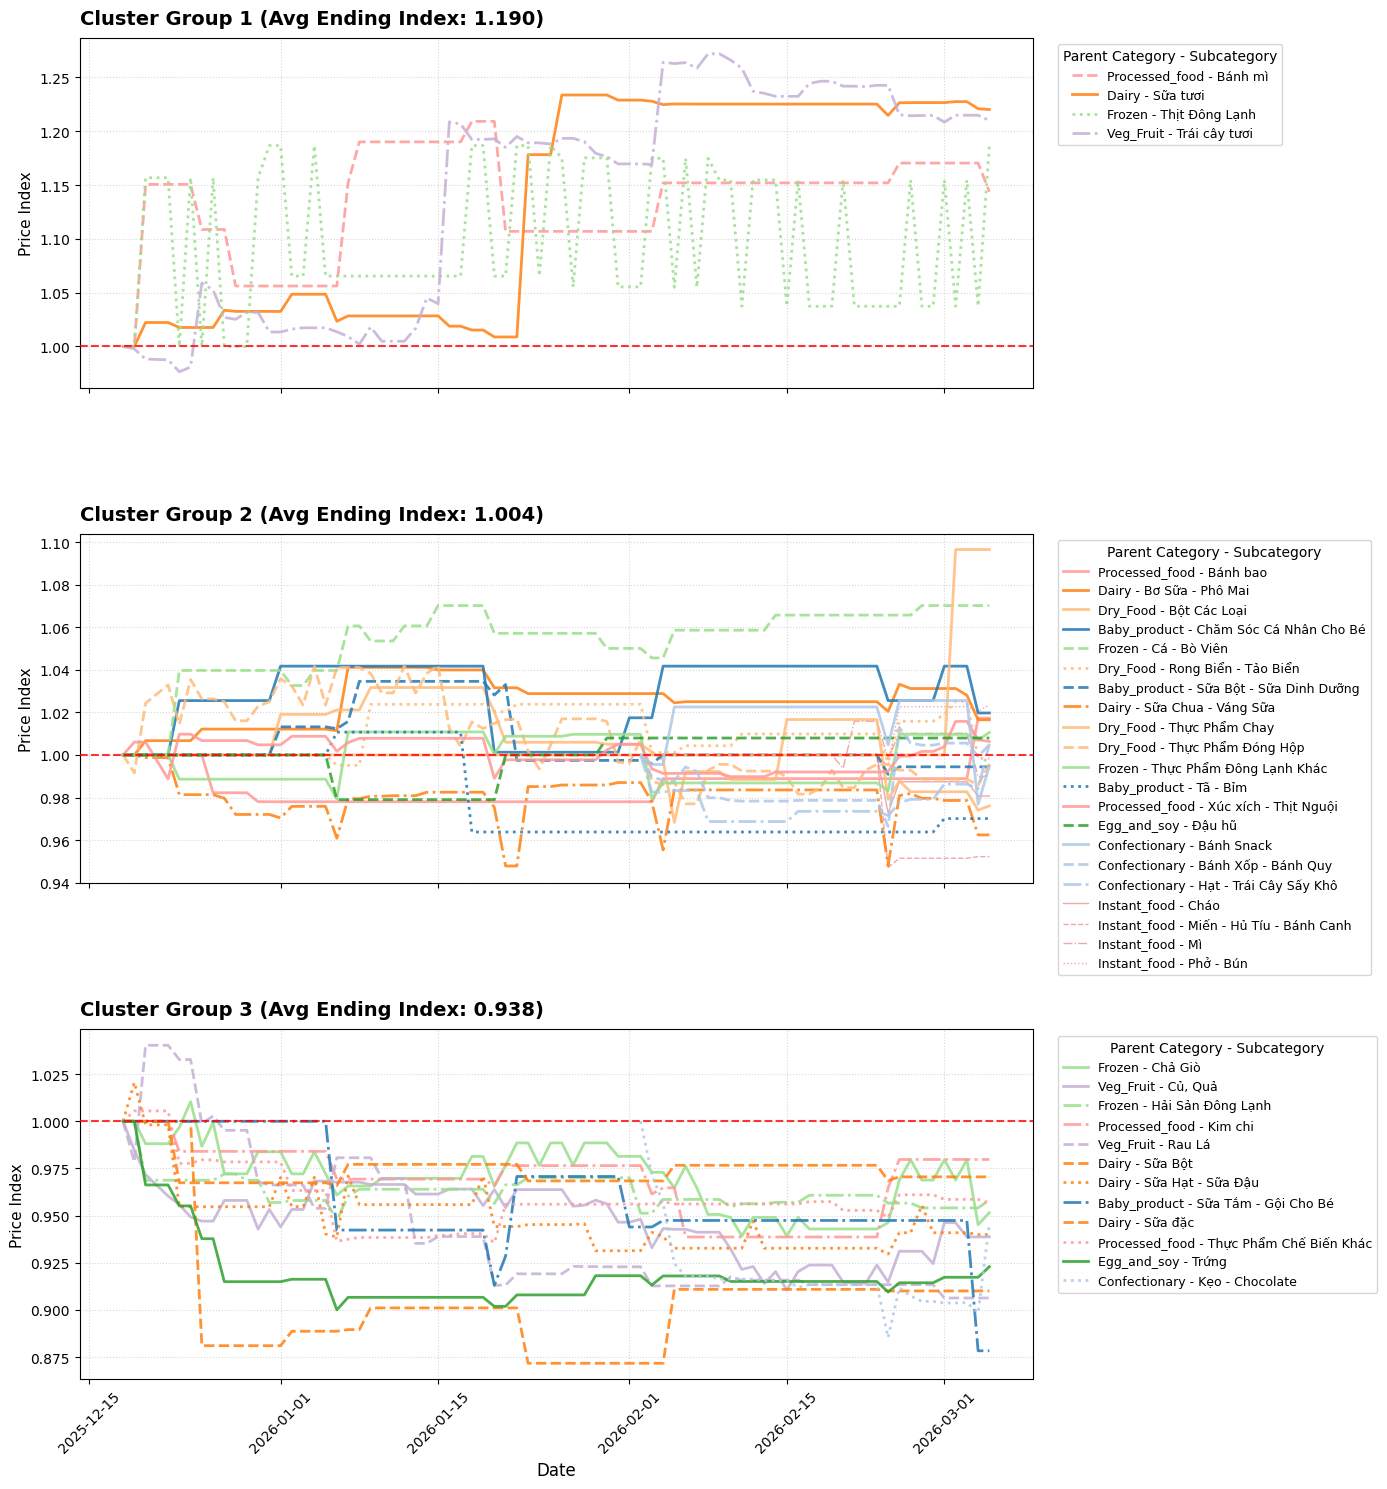

✅ Clustering mapping saved to subcategory_kmeans_groups.csv


In [11]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import matplotlib.dates as mdates

# 1. Global Setup & Data Discovery
folders = [
    'Baby_product', 'Confectionary', 'Dairy', 'Dry_Food', 
    'Egg_and_soy', 'Frozen', 'Instant_food', 'Processed_food', 
    'Spice', 'Veg_Fruit'
]

all_price_data = []
all_lookups = []

for folder in folders:
    csv_pattern = os.path.join(folder, 'CSV', '*.csv')
    lookup_path = os.path.join(folder, 'cat_lookup_table.csv')
    
    files = glob.glob(csv_pattern)
    for f in files:
        all_price_data.append(pd.read_csv(f))
        
    if os.path.exists(lookup_path):
        df_lkp = pd.read_csv(lookup_path)
        df_lkp.columns = df_lkp.columns.str.strip()
        # Added: Track the parent folder in the lookup table
        df_lkp['parent_category'] = folder 
        all_lookups.append(df_lkp)

df_raw = pd.concat(all_price_data, ignore_index=True)
df_lookup = pd.concat(all_lookups, ignore_index=True).drop_duplicates(subset=['product_name'])

# 2. Preparation & Forward Fill Logic
df_raw['date'] = pd.to_datetime(df_raw['scrape_timestamp']).dt.date
all_dates = sorted(df_raw['date'].unique())
all_products = df_raw['product_name'].unique()

multi_index = pd.MultiIndex.from_product([all_dates, all_products], names=['date', 'product_name'])
full_grid = pd.DataFrame(index=multi_index).reset_index()

df_merged = pd.merge(full_grid, df_raw[['date', 'product_name', 'final_price']], on=['date', 'product_name'], how='left')
df_merged = df_merged.sort_values(['product_name', 'date'])
df_merged['final_price'] = df_merged.groupby('product_name')['final_price'].ffill()

# Added: Include 'parent_category' in the merge
df_final = pd.merge(df_merged, df_lookup[['product_name', 'subcategory', 'parent_category']], on='product_name', how='left')
df_final = df_final.dropna(subset=['final_price', 'subcategory', 'parent_category'])

# 3. Filtering and Outlier Handling
staple_names = ['Gạo - Nông Sản Khô', 'Ngũ Cốc - Yến Mạch']
outlier_subcats = ['Phở - Bún', 'Cháo', 'Mì', 'Miến - Hủ Tíu - Bánh Canh']
cutoff_date = pd.to_datetime('2026-02-18').date()

df_others = df_final[~df_final['subcategory'].isin(staple_names)].copy()
# Resetting outlier history before Feb 18
df_others = df_others[~((df_others['subcategory'].isin(outlier_subcats)) & (df_others['date'] < cutoff_date))]

# 4. Calculation of Daily Indices
# Added: Include 'parent_category' in the groupby to retain it
daily_subcat = df_others.sort_values('date').groupby(['date', 'subcategory', 'parent_category'], as_index=False)['final_price'].mean()
daily_subcat['index'] = daily_subcat.groupby('subcategory')['final_price'].transform(lambda x: x / x.iloc[0])

# 5. K-Means Clustering Logic
# Step A: Pivot so each row is a subcategory's timeline
pivot_df = daily_subcat.pivot(index='subcategory', columns='date', values='index')

# Step B: Handle NaNs in the pivot table
pivot_df = pivot_df.ffill(axis=1).fillna(1.0)

# Step C: Run K-Means (Grouping into 3 clusters)
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
pivot_df['cluster'] = kmeans.fit_predict(pivot_df)

# Merge cluster IDs back to the long-format data
daily_subcat = daily_subcat.merge(pivot_df[['cluster']], on='subcategory', how='left')

# 6. Visualization: One panel per Cluster utilizing Global Style Manager
fig, axes = plt.subplots(n_clusters, 1, figsize=(14, 5 * n_clusters), sharex=True)

# Determine the average movement for each cluster to label them helpfully
cluster_avg = pivot_df.groupby('cluster').mean().iloc[:, -1].sort_values(ascending=False)
cluster_rank = {cluster_id: f"Cluster Group {i+1} (Avg Ending Index: {cluster_avg[cluster_id]:.3f})" for i, cluster_id in enumerate(cluster_avg.index)}

for i, cluster_id in enumerate(cluster_avg.index):
    ax = axes[i]
    subset = daily_subcat[daily_subcat['cluster'] == cluster_id]
    
    for sub in subset['subcategory'].unique():
        sub_data = subset[subset['subcategory'] == sub]
        if sub_data.empty: continue
            
        # Query the global style manager
        # Note: style_config must be initialized in your notebook
        style_info = style_config.get_style(sub)
        parent_name = style_info['parent']
        if parent_name == 'Unknown':
            parent_name = sub_data['parent_category'].iloc[0]
            
        plot_color = style_info['color']
        plot_style = style_info['linestyle']
        
        # Lower visual weight for outliers
        lw = 1.0 if sub in outlier_subcats else 2.0
        alpha = 0.4 if sub in outlier_subcats else 0.85
        zorder = 1 if sub in outlier_subcats else 5
        
        ax.plot(sub_data['date'], sub_data['index'], 
                label=f"{parent_name} - {sub}", 
                color=plot_color, linestyle=plot_style, 
                alpha=alpha, linewidth=lw, zorder=zorder)
    
    # Styling for each subplot
    ax.set_title(f"{cluster_rank[cluster_id]}", fontsize=14, fontweight='bold', loc='left', pad=10)
    ax.axhline(1.0, color='red', linestyle='--', alpha=0.8, linewidth=1.5, zorder=10)
    ax.set_ylabel("Price Index", fontsize=11)
    
    # Legend formatting
    ax.legend(title="Parent Category - Subcategory", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9, ncol=1)
    ax.grid(True, linestyle=':', alpha=0.5)

# Formatting the shared x-axis
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)
plt.xlabel("Date", fontsize=12)

plt.tight_layout()
plt.show()

# 7. Export the resulting groups for your records
pivot_df[['cluster']].to_csv('subcategory_kmeans_groups.csv')
print("✅ Clustering mapping saved to subcategory_kmeans_groups.csv")